# Setup

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 

from tqdm.auto import tqdm 
from typing import Optional, Union, List, Tuple, Dict, Any
import textwrap

### Create Virtual Instrument

In [6]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset.close()

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)

# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

### initial Dataset

In [7]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:       (sample: 6, q: 281, ds_dim: 3)
Coordinates:
  * q             (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * ds_dim        (ds_dim) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I             (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    I_noiseless   (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    dI            (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    design_space  (sample, ds_dim) int64 144B 40 0 5 40 10 5 ... 40 40 5 40 50 5
    phases        (sample) int64 48B 2 1 1 1 0 0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [9]:
def minmax_normalize(arr: np.ndarray,
                    axis: Optional[Union[int, Tuple[int, ...]]] = None,
                    eps: float = 1e-8
                ) -> np.ndarray:
    """
    Min-max normalize a NumPy array along a given axis or globally.

    Parameters:
    -----------
    arr : np.ndarray
        Input array (1D or multi-dimensional).
    axis : Optional[int or Tuple[int, ...]]
        Axis or axes along which to normalize. If None, normalize globally.
    eps : float
        Small epsilon to avoid division by zero.

    Returns:
    --------
    normalized : np.ndarray
        Normalized array with same shape as input, scaled to [0, 1].
    """
    arr = np.asarray(arr)
    min_val = np.min(arr, axis=axis, keepdims=True)
    max_val = np.max(arr, axis=axis, keepdims=True)
    normalized = (arr - min_val) / (max_val - min_val + eps)
    return normalized

### Modeling hierarchical costs in different design variables

In [10]:
class DesignSpaceHierarchyCost(PipelineOp):
    def __init__(
        self,
        grid_variable: str = None,
        grid_dim:str =None,
        component_dim:str=None,
        variables_order : List[str] = None,
        variables_offsets : List[float] = None,
        output_variable: str = None,
        name: str = "DesignSpaceHierarchyCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[grid_variable], output_variable=output_variable
        )
        self.variables_order = variables_order
        self.variables_offsets = variables_offsets
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.component_dim = component_dim
        self.iteration = 1

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Compute and store normalized cost over the full grid."""
        grid = dataset[self.grid_variable]

        cost_grid = self.evaluate_cost(query=grid)

        self.output[self.output_variable] = xr.DataArray(cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Cost per sample evaluated on {self.input_variable}"

        return self
    
    def evaluate_cost(self,
                      query: xr.DataArray,
                    ) -> np.ndarray:
        """Compute cost for each query point using previously sampled data."""
        num_queries = query.shape[0]
        k = query.shape[1]
        output = np.zeros(num_queries)
        for i in range(num_queries):
            w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
            dim_cost = []
            for j in range(k):
                ell = 1/((w[j]*self.iteration)+1)
                x = query.sel({self.component_dim: self.variables_order[j]}).values[i]
                f_x_t = ell*np.exp(-(np.abs(x-self.variables_offsets[j])*ell))
                dim_cost.append(1-f_x_t)
            output[i] = np.prod(np.array(dim_cost))

        self.iteration += 1
        return output

### Modeling unknown feasibility constraints

In [11]:
class FeasibilityLabeler(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        output_variable: str = None,
        dim: str = "sample",
        name: str = "FeasibilityLabeler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=input_variable, 
            output_variable=output_variable,
        )
        self.dim = dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Label samples as feasible or infeasible based on cost."""
        labels = dataset[self.input_variable].values
        is_feasible = np.where(labels == 0, 0, 1)  # 1 for feasible, 0 for infeasible
        self.output[self.output_variable] = xr.DataArray(is_feasible, dims=[self.dim])
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Feasibility labels based on {self.input_variable}"

        return self

### Create cost-aware acquisition function

In [12]:
class AcquisitionWithCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        cost_variables: List[str] = None,
        grid_dim: str = "grid",
        output_variable: str = None,
        name: str = "AcquisitonPerUnitCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable] + cost_variables, output_variable=output_variable
        )
        self.cost_variable = cost_variables
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        acqv = dataset[self.input_variable]
        cost = dataset[self.cost_variable]

        # Compute acquisition per unit cost
        # Q(x,t)/C(x,t)

        # acqv_cost = acqv / (cost + 1e-9)
        # norm_acqv_cost = minmax_normalize(acqv_cost)

        # Add acquisition and acquiring cost Q(x,t) + C(x,t)
        # This reduces the absurd case of sampling existing points that have zero cost
        # this maximizes the acquisition per unit cost
        # we are however assuming that acquisition and cost are measured in the same units.

        # norm_acqv_cost = minmax_normalize(acqv.values) - minmax_normalize(cost.values)

        # Anther option is to Q(x, t)*(1-C(x,t)) following 
        # https://arxiv.org/pdf/1909.03600 Equation 9 
        acqv_cost = acqv.values.copy()
        for var in self.cost_variable:
            cost = dataset[var].values
            acqv_cost *= (1.0-cost)

        # Normalize
        output = xr.DataArray(acqv_cost, dims=self.grid_dim)

        # Store result
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Acquisition with Cost (Normalized)"

        return self


### Pipelines for composition selection

In [ ]:
class UtilityCompositionSpace(PipelineOp):
    def __init__(
        self,
        input_variable: str = "acquisiton",
        cost_variables: Union[List[str], None] = None,
        composition_dims :  List[str]= ['protein', 'glycerol'],
        grid_variable:str = "design_space_grid",        
        grid_dim: str = "grid",
        output_variable: str = "composition_utility",
        name: str = "UtilityCompositionSpace",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable], 
            output_variable=output_variable
        )
        self.composition_dims = composition_dims
        self.cost_variable = cost_variables
        self.grid_variable = grid_variable 
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        next_sample = dataset[self.target_composition_variable]
        target_composition = next_sample.sel({self.target_composition_dim:self.composition_dims}).values

        grid = dataset[self.grid_variable]
        grid_composition = grid.sel({self.target_composition_dim:self.composition_dims}).values
        grid_temperatures = grid.sel({self.target_composition_dim:self.temperature_dim}).values

        squared_distances = np.sum((target_composition - grid_composition) ** 2, axis=1)
        all_temp_idx = np.argwhere(squared_distances<1e-5)

        acqv = dataset[self.input_variable]

        acqv_t = acqv.values[all_temp_idx].copy() # type: ignore
        if self.cost_variable is not None:
            for var in self.cost_variable:
                cost = dataset[var].values[all_temp_idx]
                acqv_t *= (1.0-cost)

        output = xr.DataArray(acqv_t.squeeze(), 
                              dims="d_temp",
                              coords={"d_temp": grid_temperatures[all_temp_idx].squeeze()}
                            )
        self.output[self.output_variable] = output # type: ignore
        self.output[self.output_variable].attrs["description"] = "Utility calculated along the temperature axis" # type: ignore

        return self

### Sample temperatures at a composition

In [13]:
class UtilityTemperatureAxis(PipelineOp):
    def __init__(
        self,
        input_variable: str = "acquisiton",
        cost_variables: Union[List[str], None] = None,
        target_composition_variable : str = "next_sample",
        target_composition_dim : str = "ds_dim",
        composition_dims :  List[str]= ['protein', 'glycerol'],
        temperature_dim:str = "temperature",
        grid_variable:str = "design_space_grid",        
        grid_dim: str = "grid",
        output_variable: str = "temperature_utility",
        name: str = "UtilityTemperatureAxis",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable], 
            output_variable=output_variable
        )
        self.target_composition_dim = target_composition_dim
        self.composition_dims = composition_dims
        self.temperature_dim = temperature_dim
        self.target_composition_variable = target_composition_variable       
        self.cost_variable = cost_variables
        self.grid_variable = grid_variable 
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        next_sample = dataset[self.target_composition_variable]
        target_composition = next_sample.sel({self.target_composition_dim:self.composition_dims}).values

        grid = dataset[self.grid_variable]
        grid_composition = grid.sel({self.target_composition_dim:self.composition_dims}).values
        grid_temperatures = grid.sel({self.target_composition_dim:self.temperature_dim}).values

        squared_distances = np.sum((target_composition - grid_composition) ** 2, axis=1)
        all_temp_idx = np.argwhere(squared_distances<1e-5)

        acqv = dataset[self.input_variable]

        acqv_t = acqv.values[all_temp_idx].copy() # type: ignore
        if self.cost_variable is not None:
            for var in self.cost_variable:
                cost = dataset[var].values[all_temp_idx]
                acqv_t *= (1.0-cost)

        output = xr.DataArray(acqv_t.squeeze(), 
                              dims="d_temp",
                              coords={"d_temp": grid_temperatures[all_temp_idx].squeeze()}
                            )
        self.output[self.output_variable] = output # type: ignore
        self.output[self.output_variable].attrs["description"] = "Utility calculated along the temperature axis" # type: ignore

        return self

class QueryStrategyTemperatureAxis(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        target_composition_variable : str = None,
        target_composition_dim : str = None,
        composition_dims :  List[str] = None,
        temperature_dim:str = "temperature",
        grid_variable:str = "design_space_grid",        
        grid_dim: str = "grid",
        output_variable: str = None,
        name: str = "QueryStrategyTemperatureAxis",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable], 
            output_variable=output_variable
        )
        self.composition_dims = composition_dims
        self.temperature_dim = temperature_dim
        self.target_composition_variable = target_composition_variable 
        self.target_composition_dim = target_composition_dim      
        self.grid_variable = grid_variable 
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        next_sample = dataset[self.target_composition_variable]
        target_composition = next_sample.sel({self.target_composition_dim:self.composition_dims}).values

        grid = dataset[self.grid_variable]
        grid_composition = grid.sel({self.target_composition_dim:self.composition_dims}).values
        grid_temperatures = grid.sel({self.target_composition_dim:self.temperature_dim}).values

        squared_distances = np.sum((target_composition - grid_composition) ** 2, axis=1)
        all_temp_idx = np.argwhere(squared_distances<1e-5)

        acqv = dataset[self.input_variable]

        opt_temp_idx = all_temp_idx[np.argmax(acqv.values).item()]

        output = next_sample.copy()
        output.loc[{self.target_composition_dim:self.temperature_dim}] = grid_temperatures[opt_temp_idx].item()
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = textwrap.dedent("""
        Optimal composition-temperature combination to be added to the dataset
        that maximizes the utility of acquiring a temperature measurement at any given 
        composition.
        """).strip()
        return self


### Compute cost of a measurement and synthesis

In [ ]:
class ExperimentCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        input_dim : str = None,
        composition_dims_cost :  Dict = None,
        temperature_dim_cost: Dict[str, float] = None,
        output_variable: str = None,
        name: str = "ExperimentCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=input_variable, output_variable=output_variable
        )
        self.composition_dims_cost = composition_dims_cost
        self.temperature_dim_cost = temperature_dim_cost
        self.input_dim = input_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        data = dataset[self.input_variable]
        expense = 0.0

        # Compute cost of using sample stocks
        composition_names = [key for key in self.composition_dims_cost.keys()]
        compositions = data.sel({self.input_dim:composition_names}).values
        _, indices = np.unique(compositions, axis=0, return_index=True)
        for name, val in self.composition_dims_cost.items():
            sampled_quantity = data.sel({self.input_dim:name}).values
            expense += (sampled_quantity[indices]*val).sum()

        # Compute cost of temperature modulation
        name, val = next(iter(self.temperature_dim_cost.items()))
        sampled_temperatures = data.sel({self.input_dim:name}).values
        for i in range(sampled_temperatures.shape[0]):
            if i>=1:
                expense += val*np.abs(sampled_temperatures[i] - sampled_temperatures[i-1])
            else:
                expense += val*np.abs(sampled_temperatures[i] - 27.0)

        # Store result
        output = xr.DataArray(expense)
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Total cost current experiment took so far."

        return self

### Creatte the pipeline for active learning

In [15]:
with Pipeline(name = "setup") as setup:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

setup.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid

Input Variables
---------------
0) CartesianGridGenerator
1) design_space

Output Variables
----------------
0) normalized_design_space
1) normalized_design_space_grid


In [16]:
with Pipeline(name = "select_composition") as selcomp:
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-PhaseLabels",
    )

    DesignSpaceHierarchyCost(
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        component_dim="ds_dim",
        variables_order=['temperature', 'protein', 'glycerol'],
        variables_offsets=[0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name="CompositionTemperatureHierarchyCost",
    ) 

    AcquisitionWithCost(
        input_variable="phase_entropy",
        cost_variables=["hierarchy_cost"],
        grid_dim="ds_grid",        
        output_variable="acqv_composition",
        name="Acquisition-Composition",
    )

    MaxValueAF(
        input_variables=['acqv_composition'],
        grid_variable="design_space_grid",
        grid_dim="ds_grid",
        combine_coeffs=None,
        output_prefix=None,
        output_variable="next_sample_phase",
        decision_rtol=0.05,
        excluded_comps_variables=None,
        excluded_comps_dim=None,
        exclusion_radius=0.001,
        count=1,
        name="MaxValueAF-Composition",
    )

selcomp.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
1  ) <CompositionTemperatureHierarchyCost> ['normalized_design_space_grid'] ---> hierarchy_cost
2  ) <Acquisition-Composition>           phase_entropy ---> acqv_composition
3  ) <MaxValueAF-Composition>            ['acqv_composition', 'design_space_grid'] ---> next_sample_phase

Input Variables
---------------
0) normalized_design_space
1) phases
2) normalized_design_space_grid
3) phase_entropy
4) design_space_grid

Output Variables
----------------
0) phase_y_prob
1) hierarchy_cost
2) next_sample_phase


In [17]:
with Pipeline(name = "select_temperature") as seltemp:    
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    UtilityTemperatureAxis(
        input_variable = "feasibility_entropy",
        cost_variables = None,
        target_composition_variable = "next_sample_phase",
        target_composition_dim="ds_dim",
        composition_dims = ['protein', 'glycerol'],
        temperature_dim = "temperature",
        grid_variable = "design_space_grid",        
        grid_dim = "grid",
        output_variable = "temperature_utility",
        name = "UtilityTemperatureAxis",
        )
    QueryStrategyTemperatureAxis(
        input_variable = "temperature_utility",
        target_composition_variable = "next_sample_phase",
        target_composition_dim="ds_dim",
        composition_dims = ['protein', 'glycerol'],
        temperature_dim = "temperature",
        grid_variable = "design_space_grid",        
        grid_dim = "grid",
        output_variable = "next_sample",
        name = "QueryStrategyTemperatureAxis",
    )
seltemp.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <FeasibilityLabeler>                phases ---> feasibility_labels
1  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design_space_grid'] ---> ['feasibility_y_prob']
2  ) <UtilityTemperatureAxis>            feasibility_entropy ---> temperature_utility
3  ) <QueryStrategyTemperatureAxis>      temperature_utility ---> next_sample

Input Variables
---------------
0) phases
1) normalized_design_space
2) normalized_design_space_grid
3) feasibility_entropy

Output Variables
----------------
0) feasibility_y_prob
1) next_sample


In [18]:
expense = ExperimentCost(
        input_variable="design_space",
        input_dim="ds_dim",
        composition_dims_cost={"protein":10.0, "glycerol" :5.0},
        temperature_dim_cost={"temperature" : 20.0},
        output_variable="expense",
        name="ExperimentCost"
    )

### Test Pipeline

In [19]:
ds_result = setup.calculate(ds_init)
ds_result

  0%|          | 0/3 [00:00<?, ?it/s]

<xarray.Dataset> Size: 427kB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
Dimensions without coordinates: sample, ds_grid
Data variables:
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) int64 144B 40 0 5 ... 40 50 5
    phases                        (sample) int64 48B 2 1 1 1 0 0
    design_space_grid             (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    normalized_design_space       (sample, ds_dim) float64 144B 0.5 ... 0.4167
    normalized_design_space_grid  (ds_grid, ds_dim) float64 192kB 0.0 ... 1.0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label
    gt_hull:         {'0': <trimesh.Trimesh(vertices.shape=(1675, 3), faces.s...

In [20]:
ds_result = selcomp.calculate(ds_result)
ds_result

  0%|          | 0/4 [00:00<?, ?it/s]

<xarray.Dataset> Size: 811kB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000,
                                   AF_sample: 1)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
Dimensions without coordinates: sample, ds_grid, AF_sample
Data variables: (12/15)
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) int64 144B 40 0 5 ... 40 50 5
    phases                        (sample) int64 48B 2 1 1 1 0 0
    design_space_grid             (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    ...                            ...
    phase_entropy                 (ds_grid) float64 64kB 0.9293 ... 0.9062
    phase_y_prob                  (ds_grid) float64 64kB 0.9293 ... 0.9062
    hierarchy_cost                (ds_grid) float64 64kB 0.02058 ... 0.1751
    acqv_composition              (ds_grid) float64 64kB 0.9101 ... 0.7475
    decision_surface              (ds_grid) float64 64kB 0.8752 ... 0.5262
    next_sample_phase             (AF_sample, ds_dim) float64 24B 4.211 ... 0...
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label
    gt_hull:         {'0': <trimesh.Trimesh(vertices.shape=(1675, 3), faces.s...

In [21]:
ds_result = seltemp.calculate(ds_result)
ds_result

  0%|          | 0/4 [00:00<?, ?it/s]

<xarray.Dataset> Size: 1MB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000,
                                   AF_sample: 1, d_temp: 20)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
  * d_temp                        (d_temp) float64 160B 0.0 2.632 ... 47.37 50.0
Dimensions without coordinates: sample, ds_grid, AF_sample
Data variables: (12/21)
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) int64 144B 40 0 5 ... 40 50 5
    phases                        (sample) int64 48B 2 1 1 1 0 0
    design_space_grid             (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    ...                            ...
    feasibility_labels            (sample) int64 48B 1 1 1 1 0 0
    feasibility_mean              (ds_grid) int64 64kB 1 1 1 1 1 1 ... 1 1 1 1 1
    feasibility_entropy           (ds_grid) float64 64kB 0.5964 0.595 ... 0.601
    feasibility_y_prob            (ds_grid) float64 64kB 0.5964 0.595 ... 0.601
    temperature_utility           (d_temp) float64 160B 0.5964 0.5944 ... 0.6425
    next_sample                   (AF_sample, ds_dim) float64 24B 4.211 ... 0...
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label
    gt_hull:         {'0': <trimesh.Trimesh(vertices.shape=(1675, 3), faces.s...

In [22]:
out = expense.calculate(ds_result)
out.output['expense'].values

array(885.)

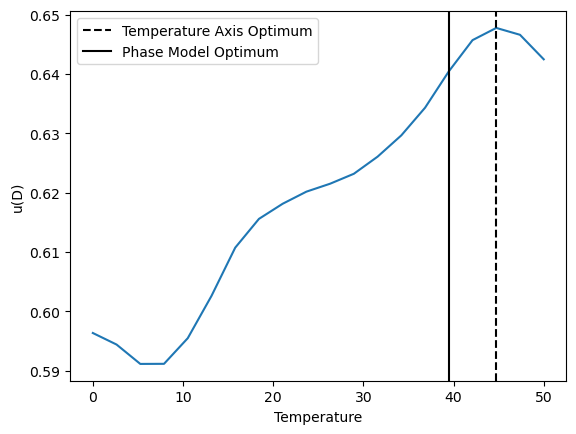

In [23]:
fig, ax = plt.subplots()
ax.plot(ds_result.temperature_utility.d_temp.values,
         ds_result.temperature_utility.values
         )
opt_temp = ds_result.next_sample.sel({"ds_dim":"temperature"}).values 
phase_sel_temp = ds_result.next_sample_phase.sel({"ds_dim":"temperature"}).values
ax.axvline(opt_temp, ls='--', color="k", label="Temperature Axis Optimum")
ax.axvline(phase_sel_temp, color="k", label="Phase Model Optimum")
ax.legend()
ax.set_xlabel("Temperature")
ax.set_ylabel("u(D)")
plt.show()


In [24]:
def plot_progress(ds, 
                  design_space_variable, 
                  grid_variable, 
                  design_space_dim, 
                  composition_variables,
                  temperature_variable,
                  labels_variable,
                  acqf_variable,
                  phase_probability_variable,
                  feasibilty_probability_variable
                  ):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(2,2, 
                             figsize=(4*2, 4*2), 
                             subplot_kw={"projection":'3d'},
                             )
    axs = axs.flatten()
    fig.subplots_adjust(wspace=0.5, hspace=0.5)

    ax = axs[0]
    x = ds[design_space_variable].sel({design_space_dim:composition_variables[0]}).values
    y = ds[design_space_variable].sel({design_space_dim:composition_variables[1]}).values
    z = ds[design_space_variable].sel({design_space_dim:temperature_variable}).values
    ax.scatter(x,y,z, c=ds[labels_variable].values, cmap='tab10')
    ax.plot(x, y, 'k*', zdir='z', zs=0.0)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap('coolwarm')
    ax = axs[1]
    xg = ds[grid_variable].sel({design_space_dim:composition_variables[0]}).values
    yg = ds[grid_variable].sel({design_space_dim:composition_variables[1]}).values
    zg = ds[grid_variable].sel({design_space_dim:temperature_variable}).values    
    mappable = ax.scatter(xg, yg, zg,
        c=ds[acqf_variable].values,
        cmap = cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(acqf_variable)

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[2]
    mappable = ax.scatter(xg, yg, zg,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(phase_probability_variable)

    ax = axs[3]
    mappable = ax.scatter(xg, yg, zg,
        c=ds[feasibilty_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(feasibilty_probability_variable)

    for ax in axs:
        ax.set_xlabel(composition_variables[0])
        ax.set_ylabel(composition_variables[1])
        ax.set_zlabel(temperature_variable, labelpad=-2)
    plt.tight_layout()

    return fig, axs

## Run AL

In [25]:
def get_running_dataset(ds_old, ds_new):
    ds = ds_new.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds = xr.concat([ds], dim='sample')

    # Only append variables that have 'sample' in their dims
    sample_vars = [var for var in ds.data_vars if 'sample' in ds[var].dims]
    non_sample_vars = [var for var in ds_old.data_vars if 'sample' not in ds_old[var].dims]

    # Get the sample and non-sample data separately
    ds_running_samples = ds_old[sample_vars]
    ds_new_samples = ds[sample_vars]
    ds_running_non_samples = ds_old[non_sample_vars]

    # Manually concatenate sample-wise data
    ds_running_samples = xr.concat([ds_running_samples, ds_new_samples], dim='sample')

    # Rebuild ds_running with updated sample vars + preserved non-sample vars
    ds_running = xr.merge([ds_running_samples, ds_running_non_samples])

    return ds_running

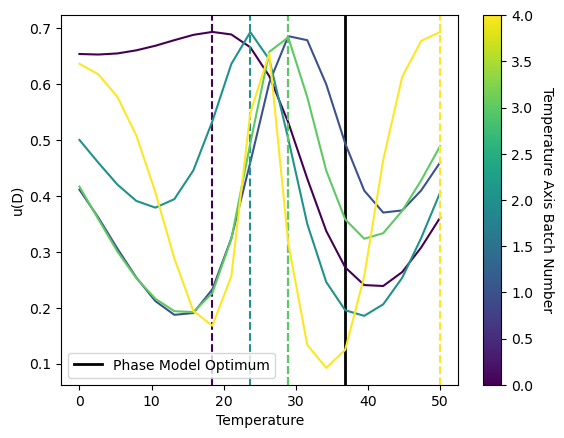

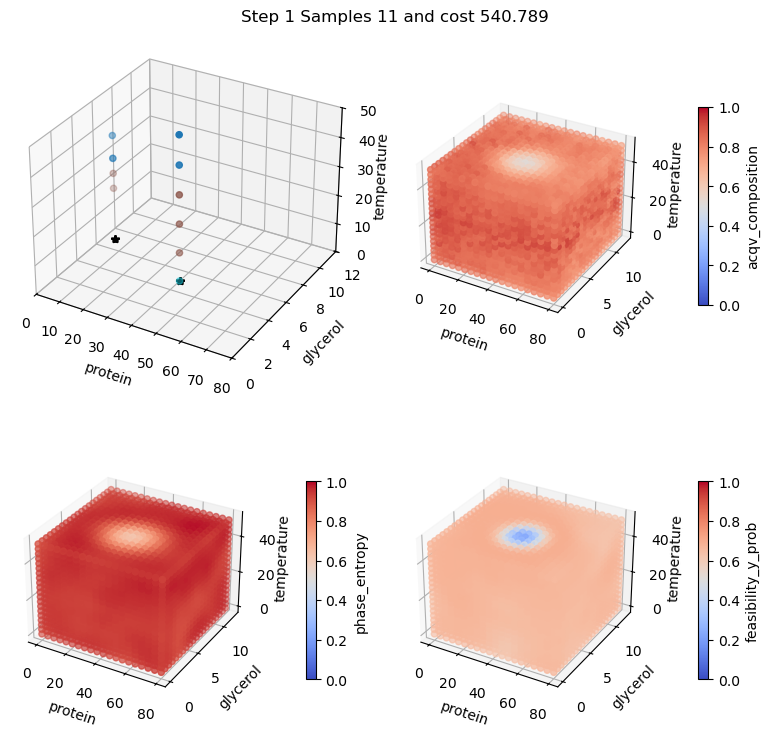

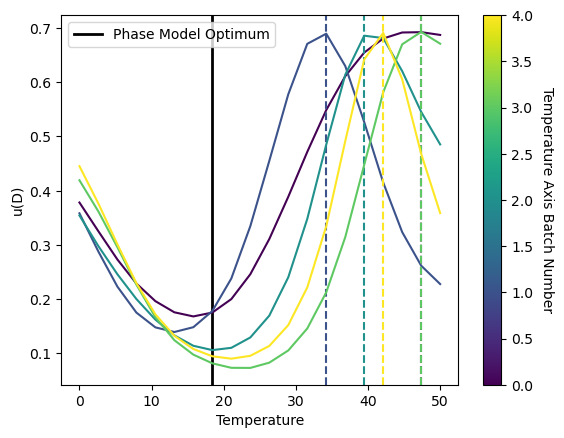

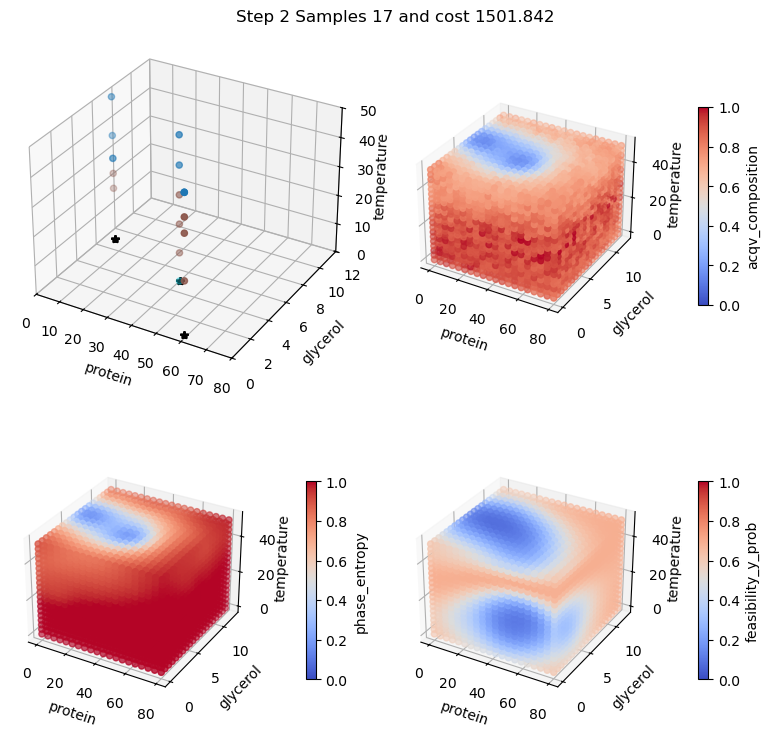

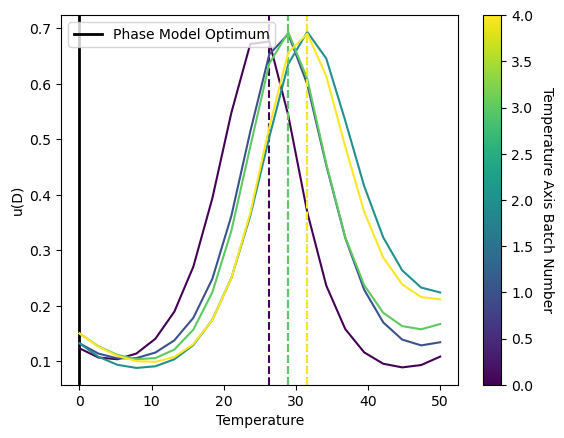

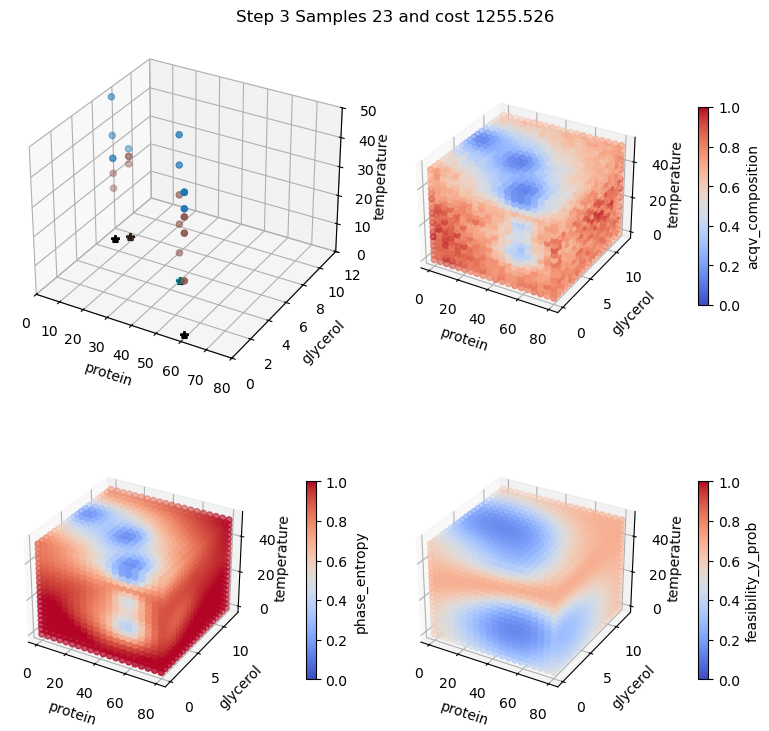

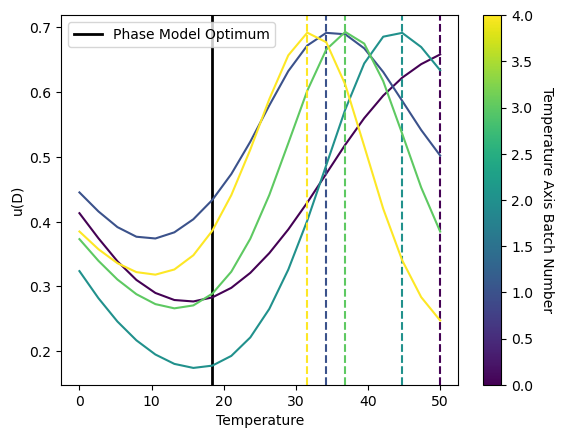

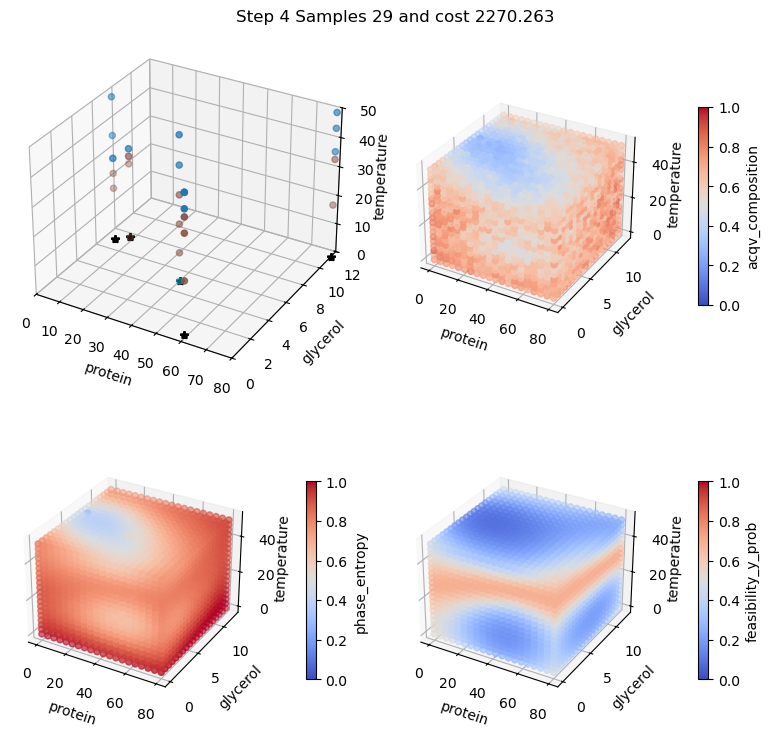

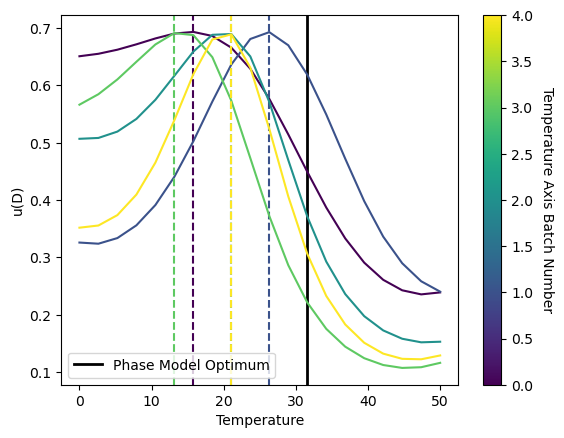

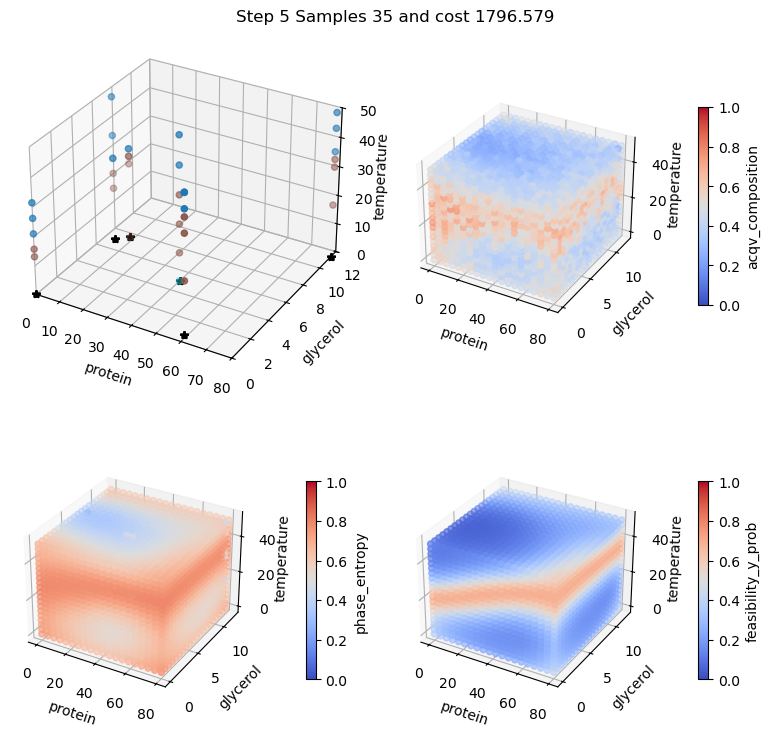

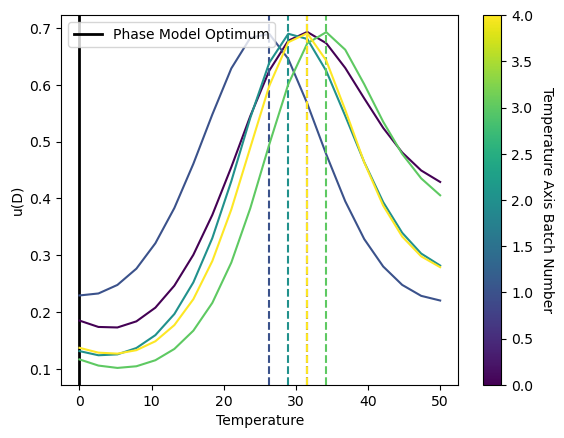

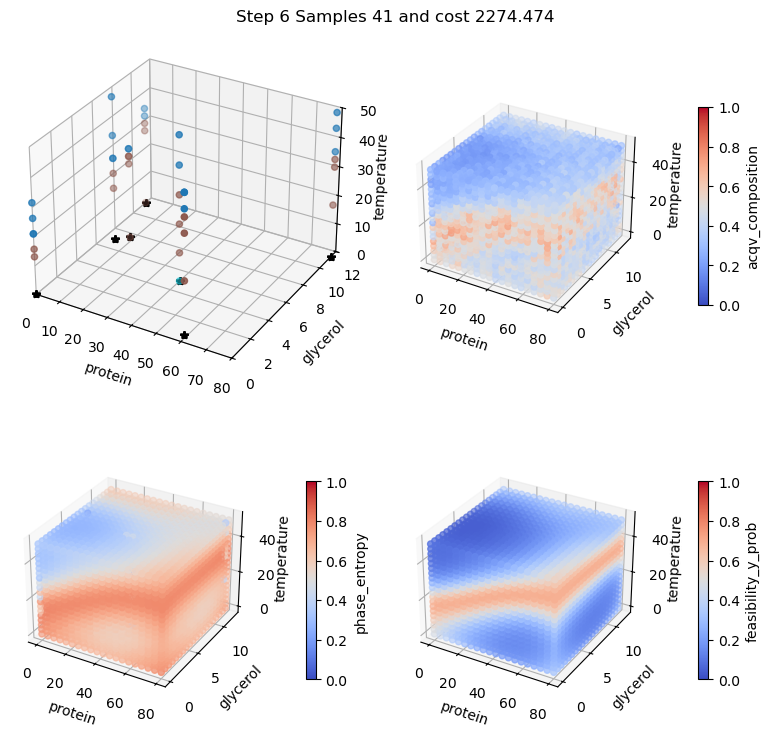

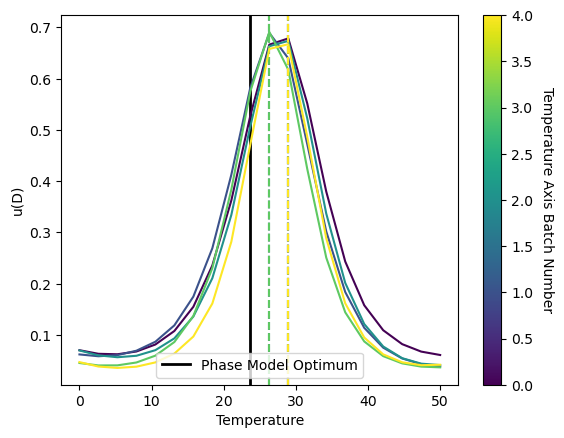

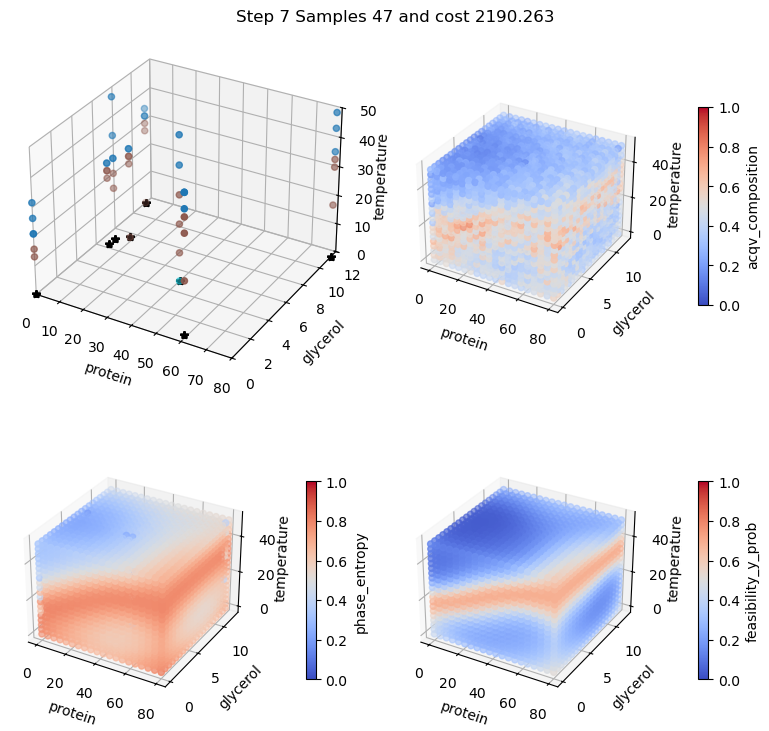

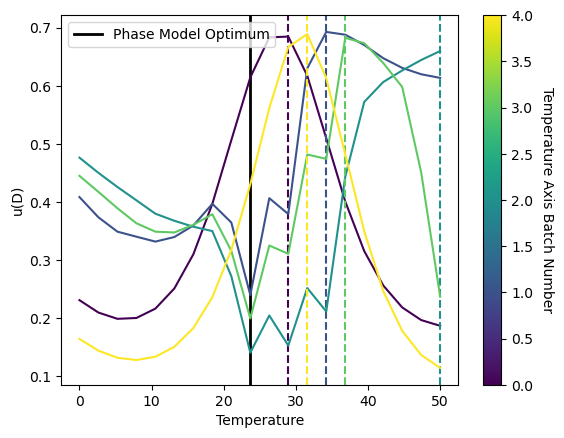

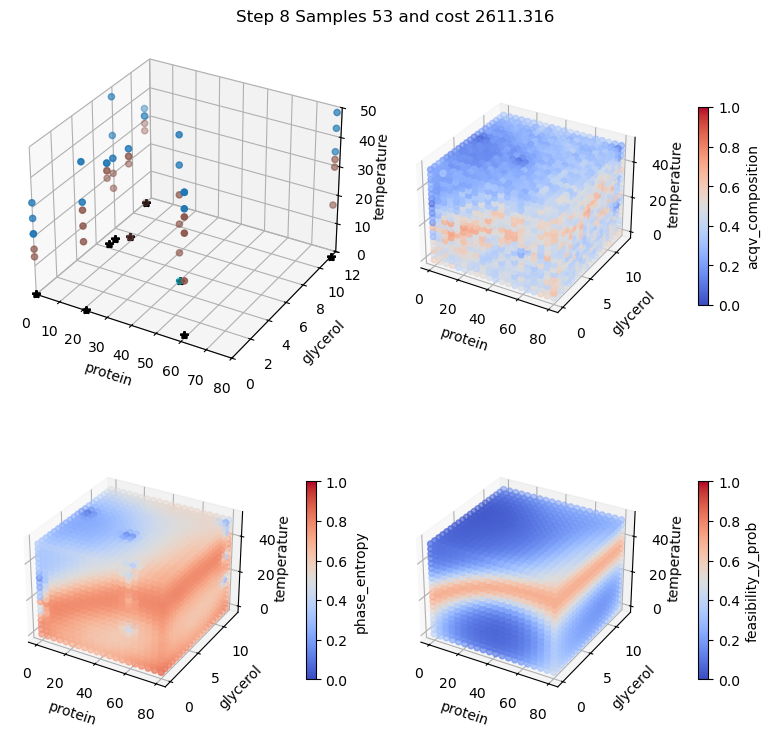

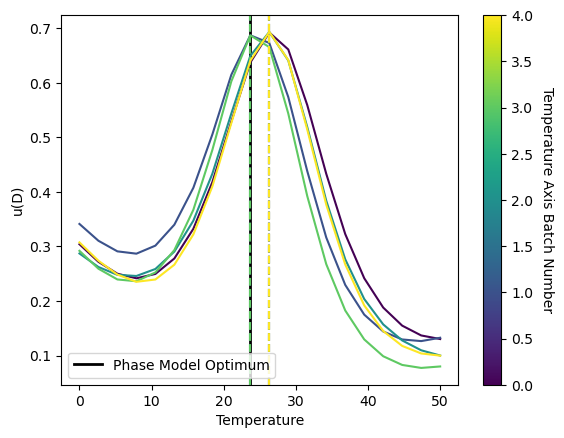

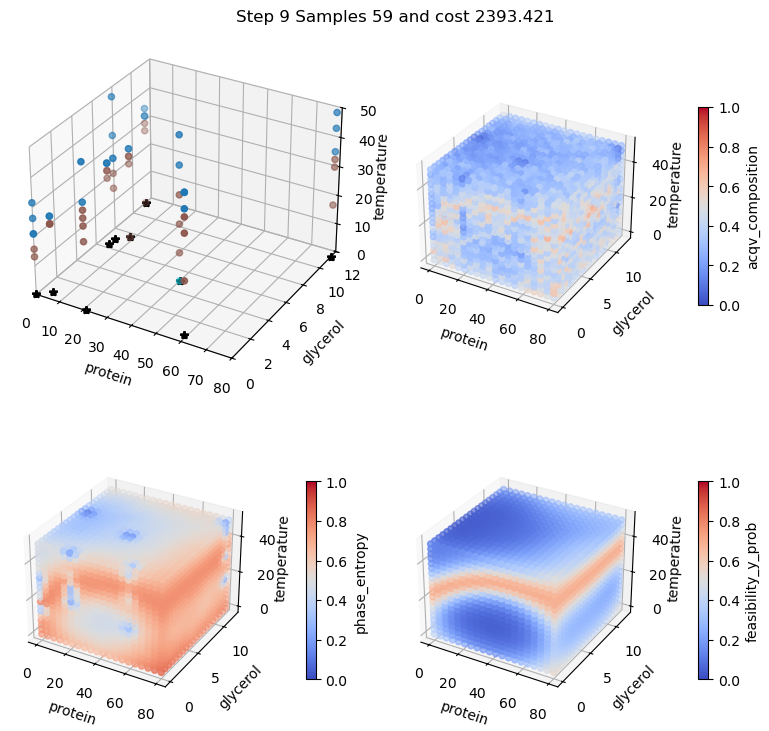

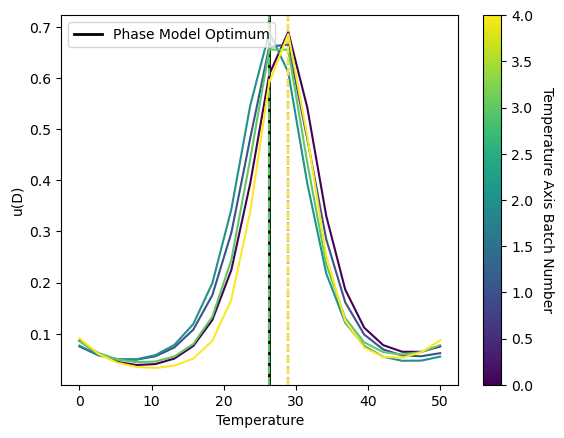

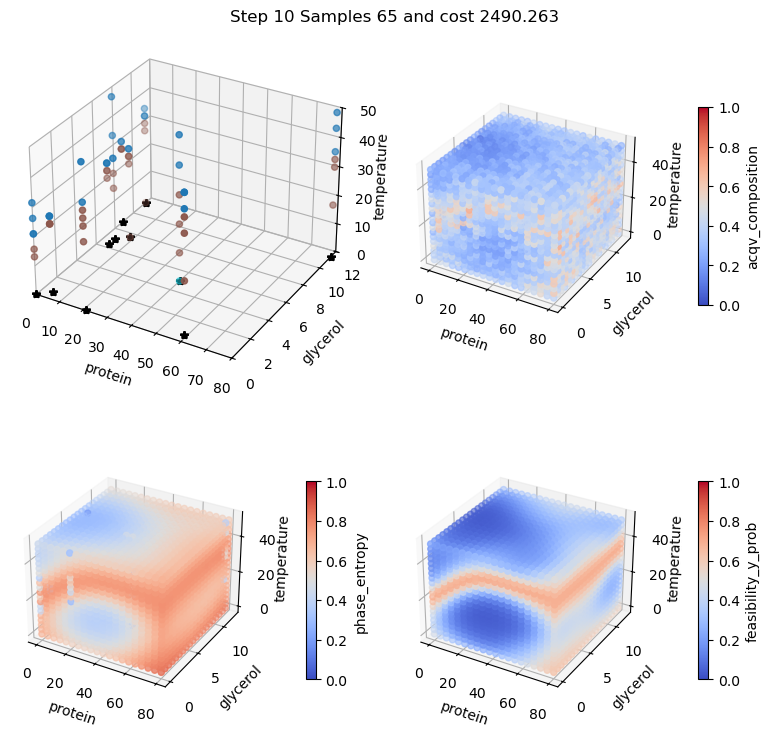

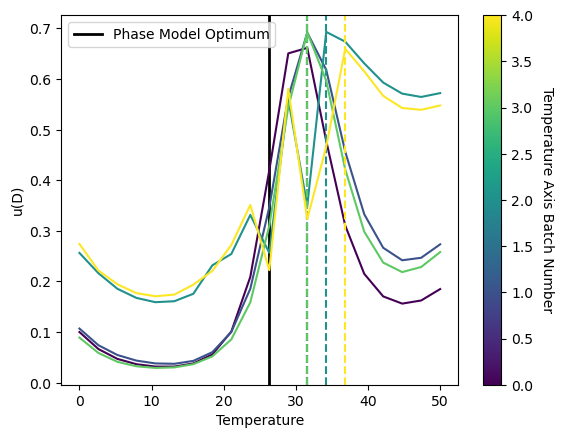

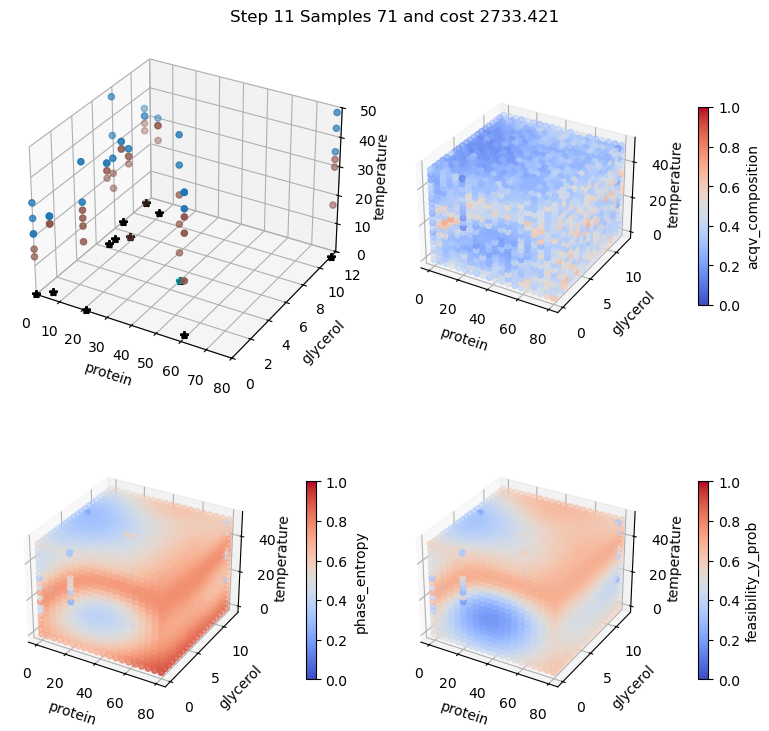

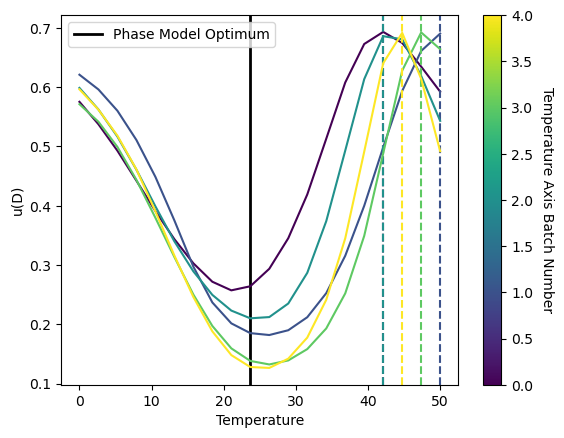

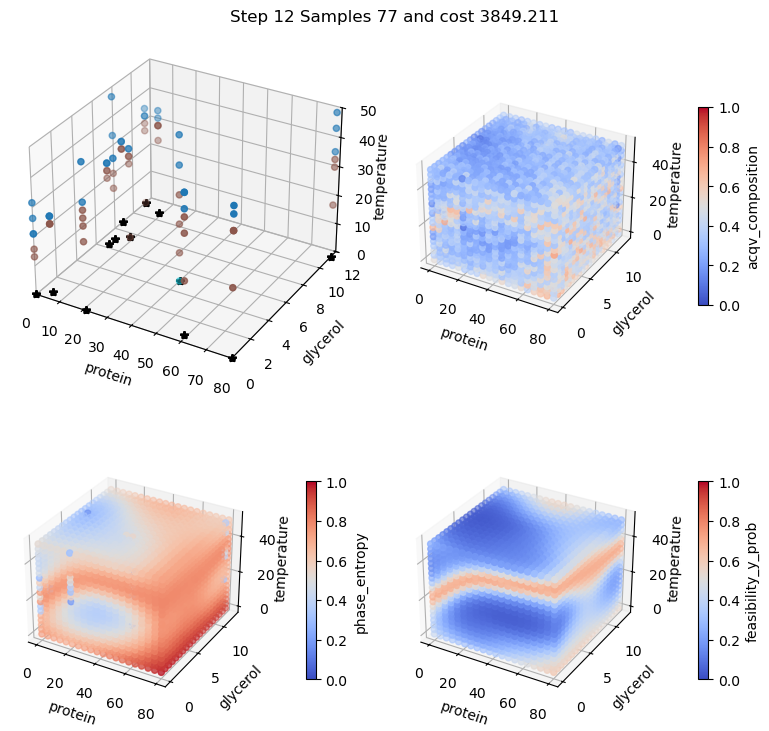

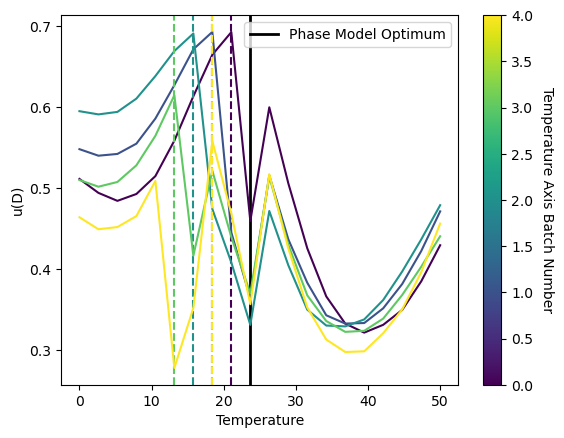

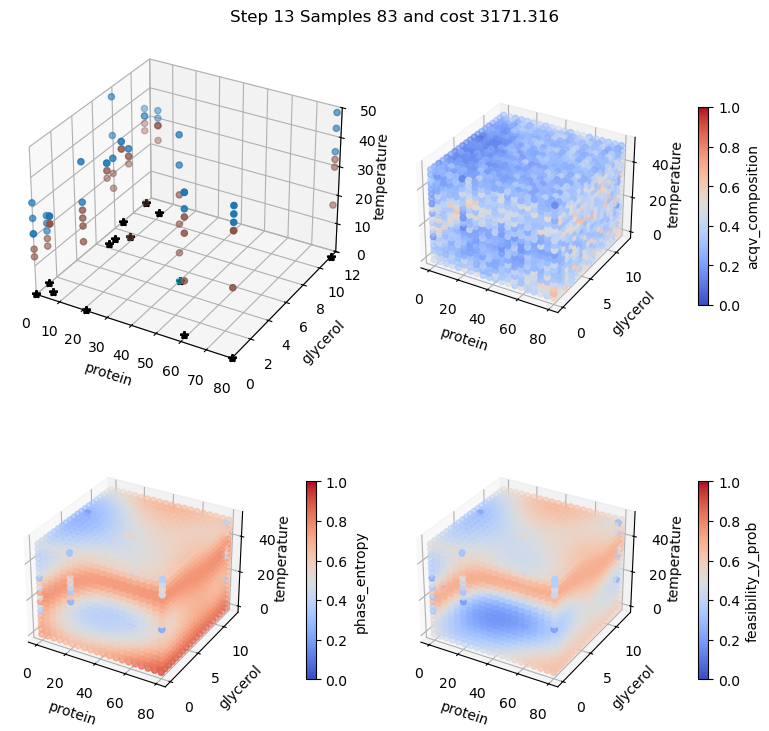

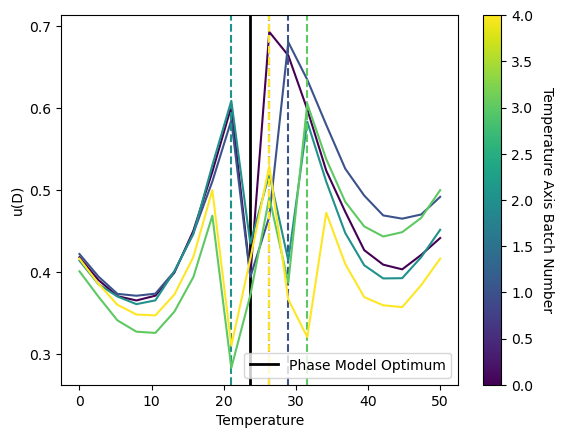

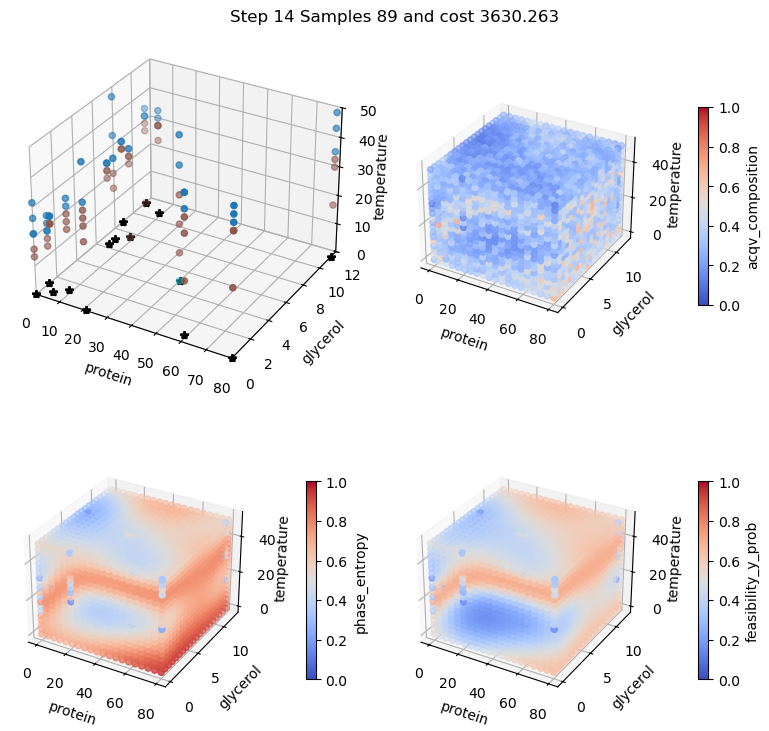

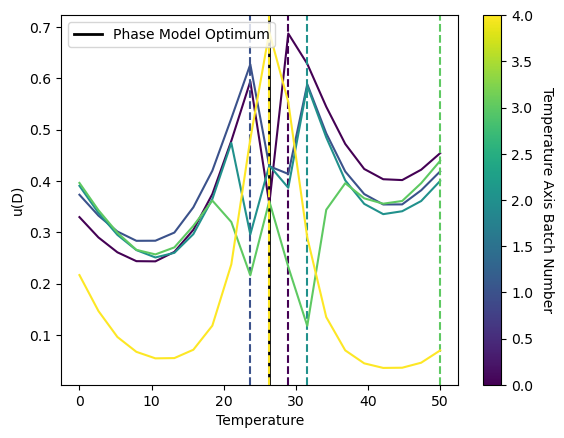

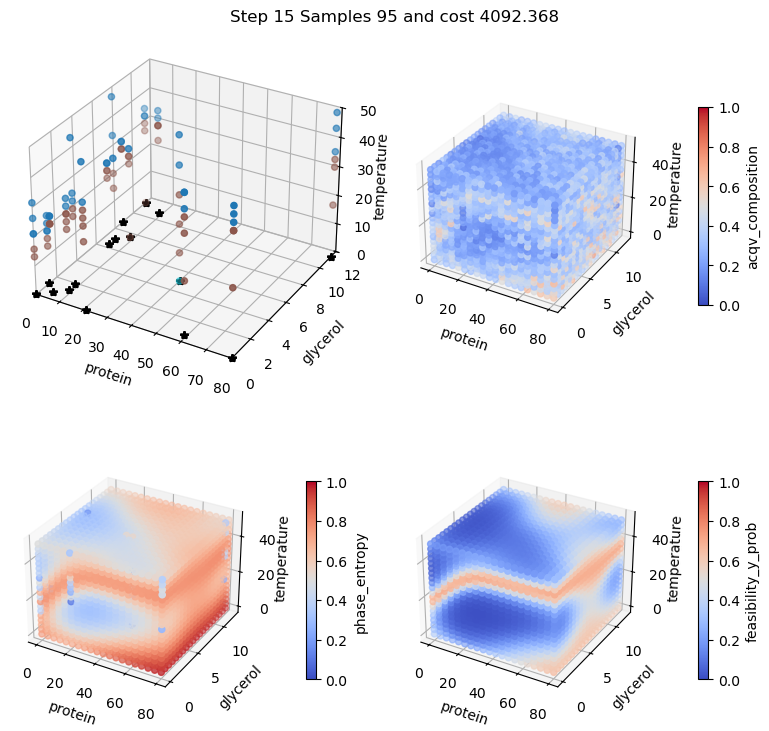

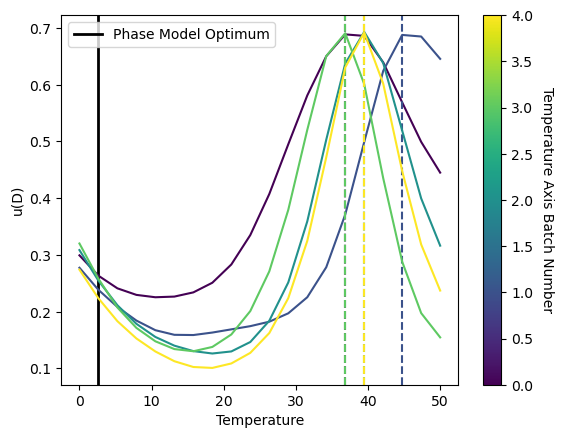

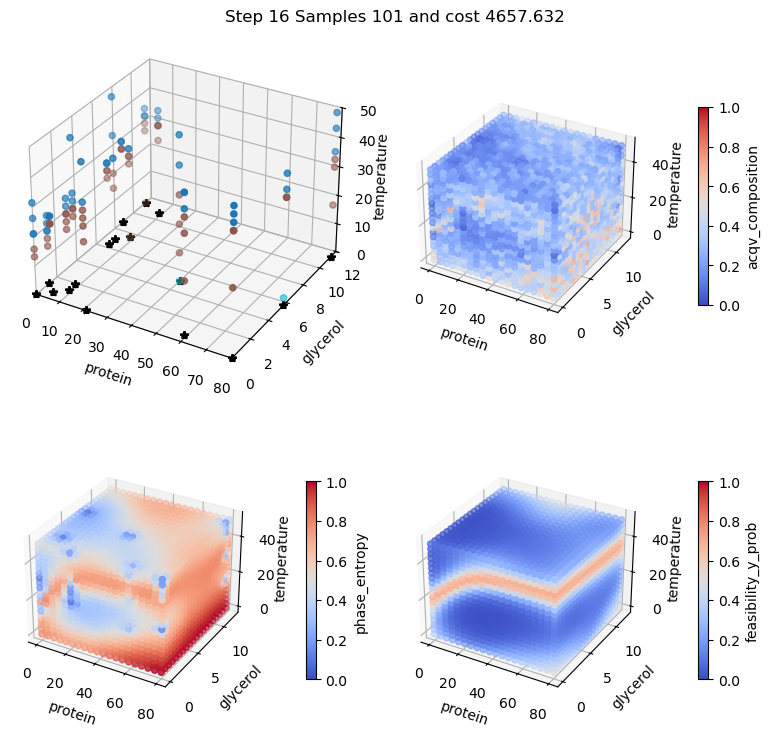

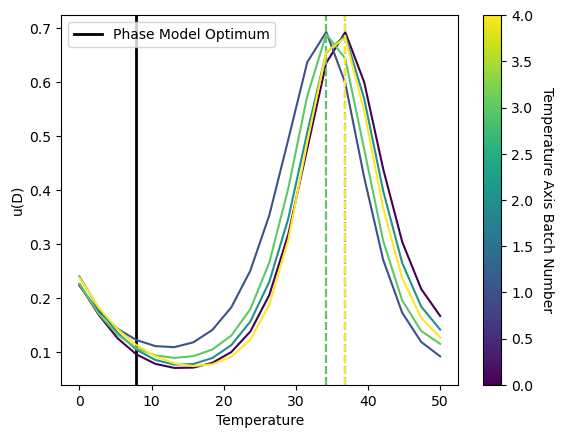

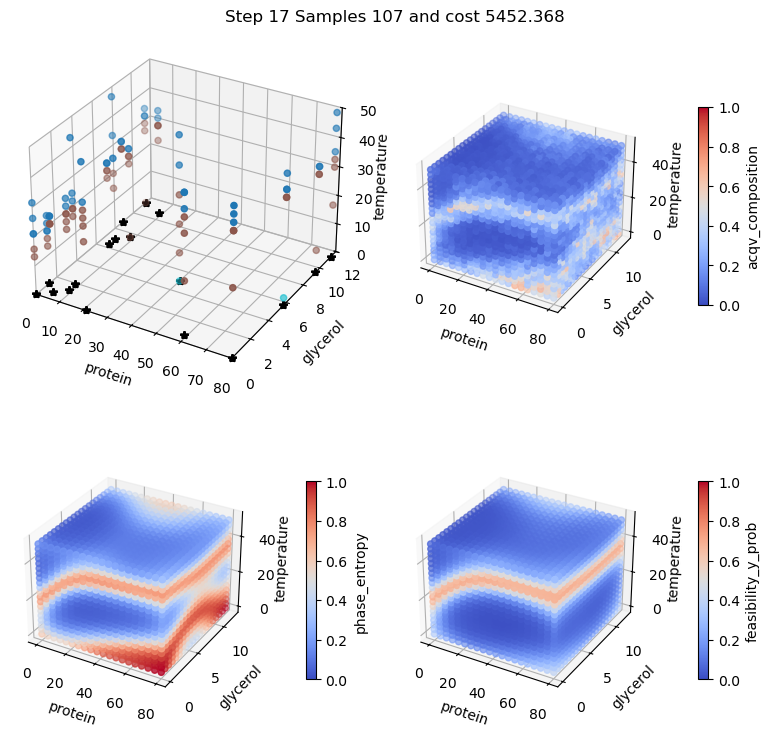

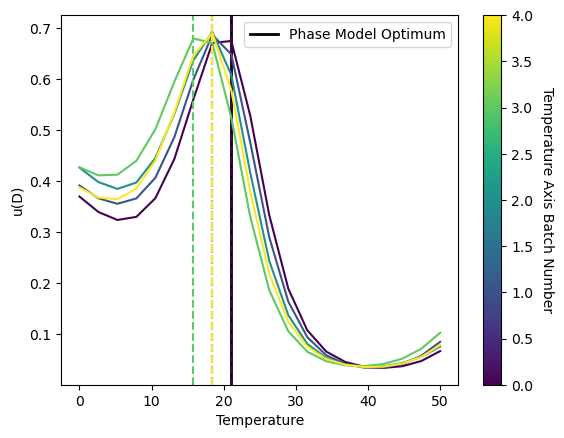

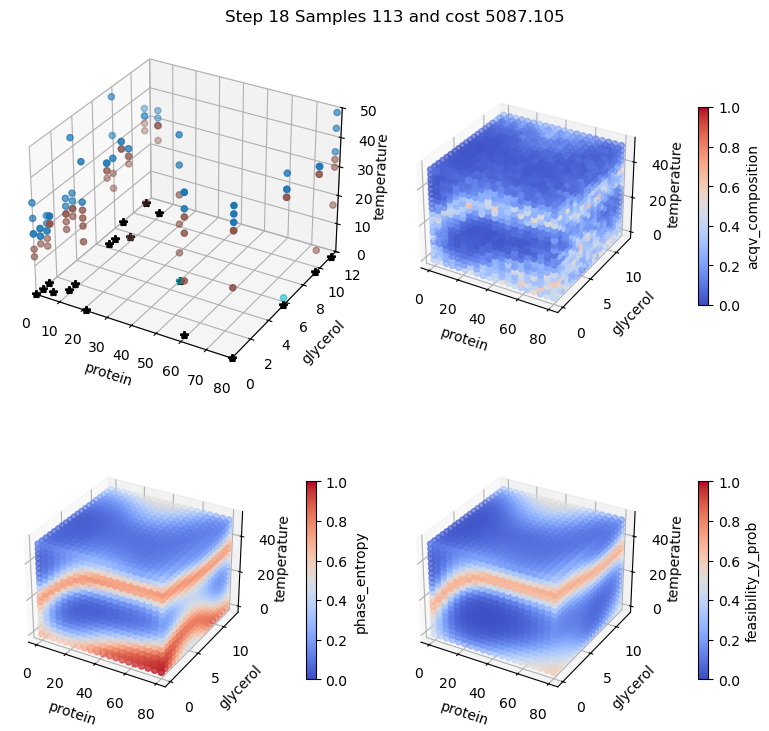

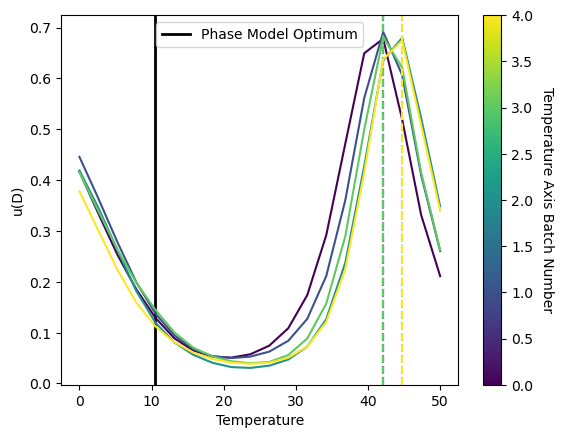

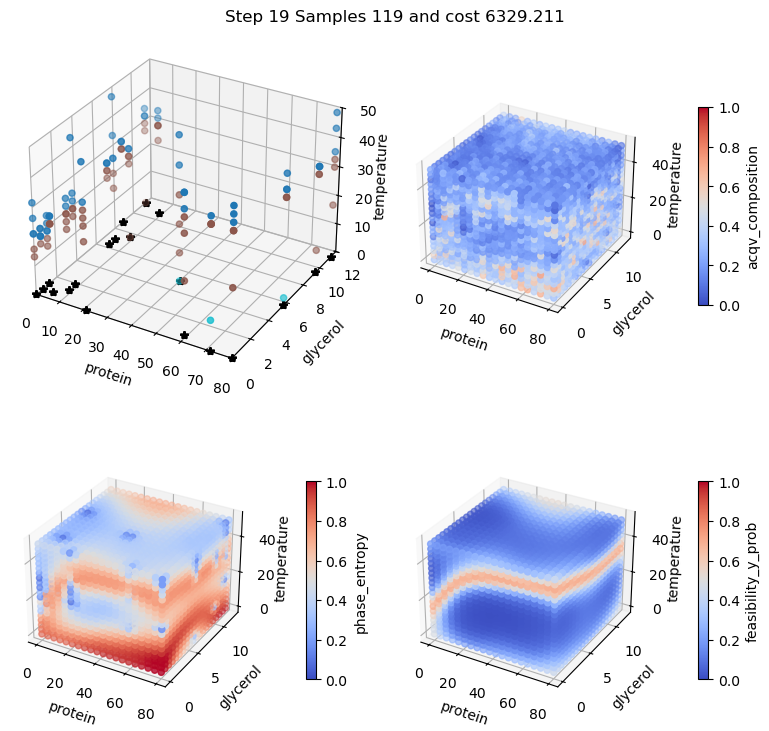

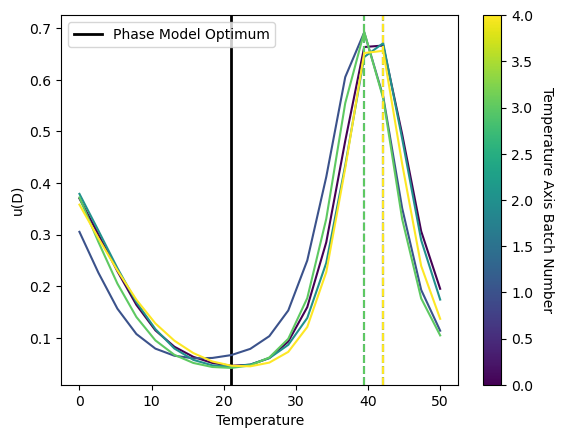

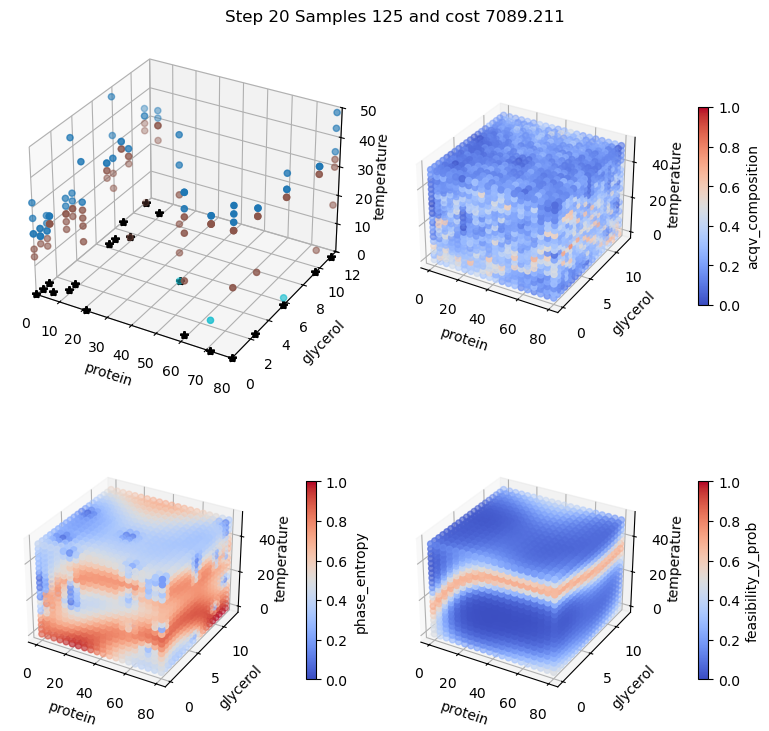

In [27]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

ds_running = ds_init.copy() 
max_samples = 100 
temp_batch_size = 5
num_samples = 20

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, temp_batch_size))
norm = Normalize(vmin=0, vmax=temp_batch_size-1)
for step in range(num_samples):
    ds_result = setup.calculate(ds_running, disable_progress_bar=True)
    ds_result = selcomp.calculate(ds_result, disable_progress_bar=True)
    ds_running['next_sample_phase'] = ds_result['next_sample_phase']
    ds_running['phase_entropy'] = ds_result['phase_entropy']
    ds_running['acqv_composition'] = ds_result['acqv_composition']

    # Measure sample that improves phase boundaries
    next_sample_comp = ds_result['next_sample_phase'].to_pandas().to_dict(orient='records')[0]   # type: ignore
    ds = inst_client.simple_expose(next_sample_comp)
    ds_running = get_running_dataset(ds_running, ds)

    # Measure sample at the same composition as before but at different temperatures.
    # We update the feasibility model each time, and sample a temperature that helps us
    # decode the feasibility boundary better.
    fig, ax = plt.subplots()
    phase_sel_temp = ds_result.next_sample_phase.sel({"ds_dim":"temperature"}).values
    ax.axvline(phase_sel_temp, color="k", lw=2.0, label="Phase Model Optimum")

    for i in range(temp_batch_size):
        ds_result = setup.calculate(ds_running, disable_progress_bar=True)
        ds_result = seltemp.calculate(ds_result, disable_progress_bar=True)
        next_sample = ds_result['next_sample'].to_pandas().to_dict(orient='records')[0]   # type: ignore
        ds = inst_client.simple_expose(next_sample)
        ds_running = get_running_dataset(ds_running, ds)
        color = colors[i]
        ax.plot(ds_result.temperature_utility.d_temp.values,
                ds_result.temperature_utility.values,
                color = color
            )
        opt_temp = ds_result.next_sample.sel({"ds_dim":"temperature"}).values 
        ax.axvline(opt_temp, ls='--', color=color)
    ax.legend()
    ax.set_xlabel("Temperature")
    ax.set_ylabel("u(D)")
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Temperature Axis Batch Number', rotation=270, labelpad=15)
    plt.show()

    out = expense.calculate(ds_result)
    
    fig, axs = plot_progress(ds_result, 
                  "design_space", 
                  "design_space_grid", 
                  "ds_dim", 
                  ['protein', 'glycerol'],
                  "temperature",
                  "phases",
                  "acqv_composition",
                  "phase_entropy",
                  "feasibility_y_prob"
                  )
    fig.suptitle(f"Step {step+1} Samples {len(ds_result.sample)} " + 
                 f"and cost {out.output['expense'].values.item():.3f}")
    plt.show()

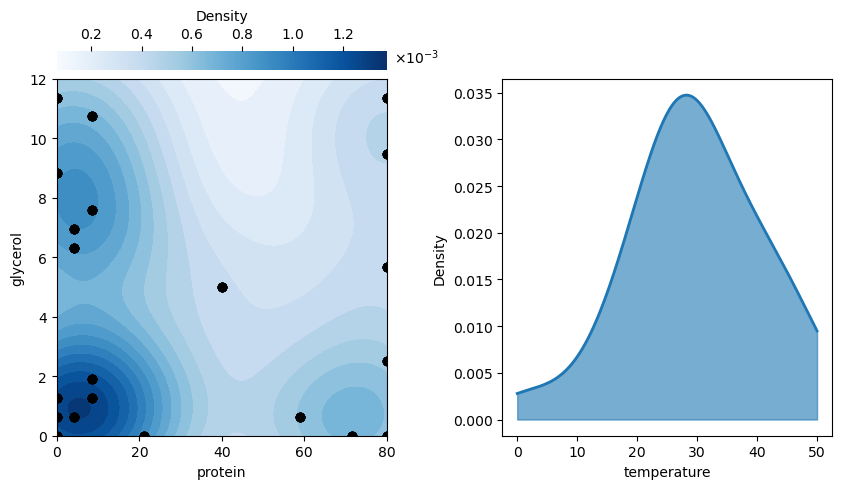

In [28]:
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import matplotlib.transforms as mtransforms

design_space_variable = "design_space"
design_space_dim = "ds_dim"
composition_variables = ["protein", "glycerol"]
temperature_variable = "temperature"

x = ds_result[design_space_variable].sel({design_space_dim: composition_variables[0]}).values
y = ds_result[design_space_variable].sel({design_space_dim: composition_variables[1]}).values
z = ds_result[design_space_variable].sel({design_space_dim: temperature_variable}).values

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(nrows=2, 
                       ncols=2, 
                       height_ratios=[0.05, 0.95], 
                       hspace=0.05, wspace=0.35)

ax_cb = fig.add_subplot(gs[0, 0])       # colorbar axis above left plot
ax_kde = fig.add_subplot(gs[1, 0])      # 2D KDE plot
ax_hist = fig.add_subplot(gs[1, 1])     # 1D KDE plot

# --- 2D KDE of (x, y) ---
xy = np.vstack([x, y])
kde_xy = gaussian_kde(xy, bw_method=0.5)

# Grid
xgrid = np.linspace(0, 80, 100)
ygrid = np.linspace(0, 12, 100)
X, Y = np.meshgrid(xgrid, ygrid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde_xy(positions).T, X.shape)

# Plot 2D density
cf = ax_kde.contourf(X, Y, Z, levels=20, cmap='Blues')
ax_kde.scatter(x,y, color="k")
ax_kde.set_xlabel(composition_variables[0])
ax_kde.set_ylabel(composition_variables[1])
ax_kde.set_xlim([0.0, 80.0])
ax_kde.set_ylim([0.0, 12.0])

# Add horizontal colorbar above ax_kde
norm = Normalize(vmin=Z.min(), vmax=Z.max())
sm = ScalarMappable(norm=norm, cmap='Blues')
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
cbar.set_label("Density", labelpad=5)
ax_cb.xaxis.set_ticks_position('top')
ax_cb.xaxis.set_label_position('top')

# Use scientific notation with offset (e.g., 1e-3)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))  # force sci notation if outside range
ax_cb.xaxis.set_major_formatter(formatter)
offset_text = ax_cb.xaxis.get_offset_text()
# Anchor left and top as before
offset_text.set_horizontalalignment('left')
offset_text.set_verticalalignment('top')
# Remove the default transform and set a new one with an offset in display coords
trans = offset_text.get_transform()  # usually data or axes coords
# Add an offset in display coords (pixels): x=+20 pixels, y=-10 pixels (down)
offset = mtransforms.ScaledTranslation(5/72, -18/72, fig.dpi_scale_trans)
offset_text.set_transform(trans + offset) 


# Remove cb axis border for aesthetics
for spine in ax_cb.spines.values():
    spine.set_visible(False)

# --- 1D KDE of z ---
kde_z = gaussian_kde(z, bw_method=0.5)
zgrid = np.linspace(z.min(), z.max(), 200)
density = kde_z(zgrid)

ax_hist.fill_between(zgrid, density, color="tab:blue", alpha=0.6)
ax_hist.plot(zgrid, density, color="tab:blue", lw=2.0)
ax_hist.set_xlabel(temperature_variable)
ax_hist.set_ylabel("Density")

plt.show()
